In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [9]:
dataset1 = pd.read_csv('/content/drive/MyDrive/DEEP LEARNING /DEEP LEARNING.csv')
X = dataset1[['INPUT']].values
y = dataset1[['OUTPUT']].values

In [20]:
dataset1.head()

,INPUT,OUTPUT
0,9,78
1,6,56
2,5,45
3,5,12
4,0,45


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [13]:
import torch.nn as nn

class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}
  def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x

In [14]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
ai_brain=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.Adam(ai_brain.parameters(),lr=0.001)

In [4]:
# Name:SHARVESHWARAN SS
# Register Number:212224220096
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        # Forward pass
        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [15]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 2368.964355
Epoch [200/2000], Loss: 2218.637695
Epoch [400/2000], Loss: 1619.917969
Epoch [600/2000], Loss: 857.916016
Epoch [800/2000], Loss: 600.500732
Epoch [1000/2000], Loss: 562.865601
Epoch [1200/2000], Loss: 539.940613
Epoch [1400/2000], Loss: 522.423401
Epoch [1600/2000], Loss: 509.916656
Epoch [1800/2000], Loss: 501.752991


In [16]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 1457.279785


In [17]:
loss_df = pd.DataFrame(ai_brain.history)

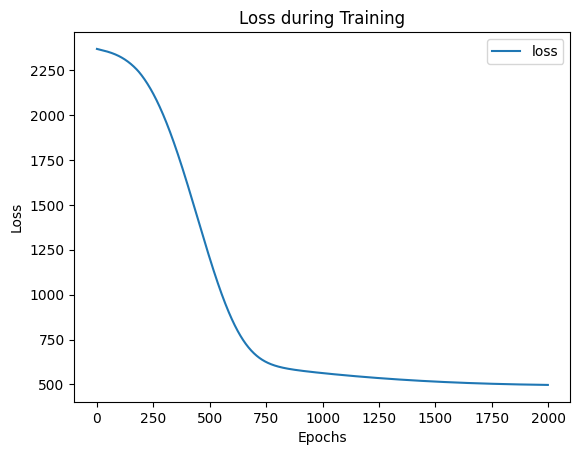

In [18]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [19]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 40.440773010253906
